Saved: /user/ab5405/summeraliaclimate/code/energy_uncertainty/figures/python_compare/overlay_lines_3x3_FD_FGLS_inter_TINV_clim_quadinter_electricity_full_year2010.pdf


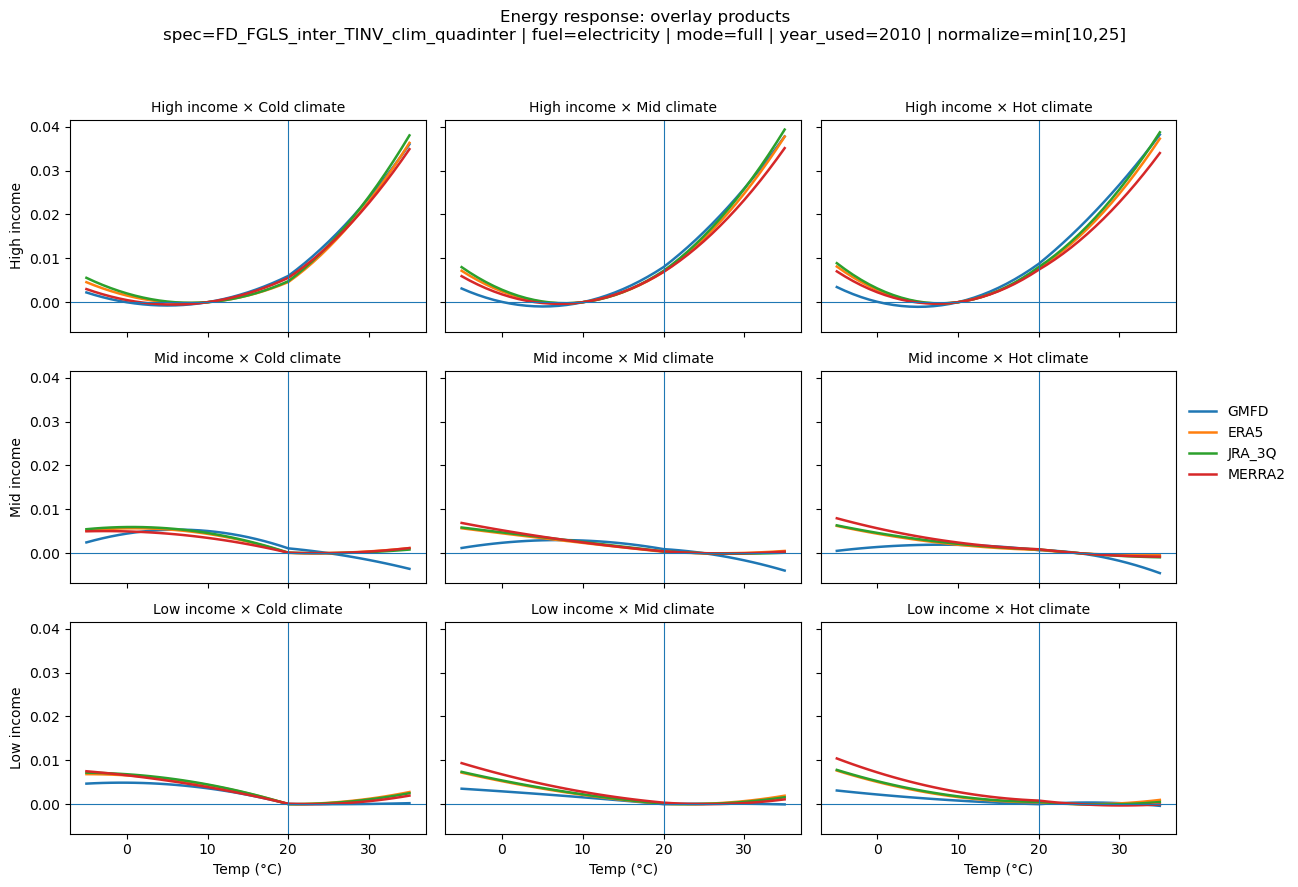

In [18]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================
EU = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty")
STERD = EU / "data" / "regression" / "sters"

EDR = Path("/user/ab5405/summeraliaclimate/code/energy_consumption/energy_data_release_2021oct21/DATA/regression")
BREAK_DATA = EDR / "break_data_TINV_clim.dta"

# ============================================================
# SETTINGS
# ============================================================
PRODUCTS = ["GMFD", "ERA5", "JRA_3Q", "MERRA2"]
FUEL = "electricity"               # "electricity" or "other_energy"
IND_F = 1

MODEL_STEM = "FD_FGLS_inter_TINV_clim_quadinter"

T = np.arange(-5, 36, 1.0)
ABOVE20 = (T >= 20).astype(float)
BELOW20 = (T < 20).astype(float)

NORMALIZE_MIN_10_25 = True
SLICE_MIN, SLICE_MAX = 10, 25

# Choose what you want:
#   "full" = matches Stata quadinter figure logic (uses year and year^2)
#   "baseline" = excludes year and year^2 blocks
PLOT_MODE = "full"

YEAR_USED = 2010 

OUTDIR = EU / "figures" / "python_compare"
OUTDIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================
def must_exist(p: Path, label="file"):
    if not p.exists():
        raise FileNotFoundError(f"Missing {label}: {p}")

def read_coeff_csv(path: Path) -> pd.Series:
    df = pd.read_csv(path)
    if not {"parm", "beta"}.issubset(df.columns):
        raise ValueError(f"Expected parm,beta in {path}, got {df.columns.tolist()}")
    parm = df["parm"].astype(str).str.strip()   # <<< IMPORTANT
    beta = df["beta"].astype(float)
    return pd.Series(beta.values, index=parm.values)

def ibar_from_breakdata(bd: pd.DataFrame, fuel: str) -> float:
    maxcol = f"maxInc_largegpid_{fuel}"
    flagcol = f"largegpid_{fuel}"
    return float(bd.loc[bd[flagcol] == 1, maxcol].max())

def prep_income_map(bd: pd.DataFrame):
    inc_by_lg = bd.groupby("tgpid")["avgInc_tgpid"].mean().to_dict()
    return {int(k): float(v) for k, v in inc_by_lg.items()}

def prep_climate_maps(bd: pd.DataFrame):
    cdd_by_tr = bd.groupby("tpid")["avgCDD_tpid"].mean().to_dict()
    hdd_by_tr = bd.groupby("tpid")["avgHDD_tpid"].mean().to_dict()
    return ({int(k): float(v) for k, v in cdd_by_tr.items()},
            {int(k): float(v) for k, v in hdd_by_tr.items()})

def normalize_curve(y: np.ndarray) -> np.ndarray:
    if not NORMALIZE_MIN_10_25:
        return y
    win = (T >= SLICE_MIN) & (T <= SLICE_MAX)
    return y - np.min(y[win])

def parm_candidates(pg: int, indf: int, term: str, product: str) -> list[str]:
    # Try with suffix and without; also "co." vs "c."
    return [
        f"c.indp{pg}#c.indf{indf}#c.{term}_{product}",
        f"c.indp{pg}#c.indf{indf}#c.{term}",
        f"co.indp{pg}#co.indf{indf}#co.{term}_{product}",
        f"co.indp{pg}#co.indf{indf}#co.{term}",
    ]

def resolve_name(coef_index: pd.Index, pg: int, indf: int, term: str, product: str):
    # exact match first
    for nm in parm_candidates(pg, indf, term, product):
        if nm in coef_index:
            return nm
    return None

def build_design_quadinter(
    coef_index: pd.Index,
    *,
    fuel: str,
    product: str,
    subInc: float,
    subCDD: float,
    subHDD: float,
    ibar: float,
    year_used: int,
    indf: int,
    plot_mode: str,
):
    """
    plot_mode:
      - "full": match Stata quadinter figure logic (includes year and year^2 blocks)
      - "baseline": exclude year/year^2 blocks entirely (form comparisons)
    """
    pg = 1 if fuel == "electricity" else 2
    ig = 2 if subInc > ibar else 1
    deltacut = float(subInc - ibar)

    y = float(year_used)
    y2 = y * y

    names, cols = [], []

    for k in [1, 2]:
        Tk = T ** k
        base = Tk - (20.0 ** k)
        below = (20.0 ** k) - Tk

        # core terms
        nm_temp = resolve_name(coef_index, pg, indf, f"FD_temp{k}", product)
        nm_cdd  = resolve_name(coef_index, pg, indf, f"FD_cdd20_TINVtemp{k}", product)
        nm_hdd  = resolve_name(coef_index, pg, indf, f"FD_hdd20_TINVtemp{k}", product)
        nm_dc1  = resolve_name(coef_index, pg, indf, f"FD_dc1_lgdppc_MA15I{ig}temp{k}", product)

        if nm_temp:
            names.append(nm_temp); cols.append(base)
        if nm_cdd:
            names.append(nm_cdd); cols.append(ABOVE20 * subCDD * base)
        if nm_hdd:
            names.append(nm_hdd); cols.append(BELOW20 * subHDD * below)
        if nm_dc1:
            names.append(nm_dc1); cols.append(deltacut * base)

        if plot_mode == "full":
            # year and year^2 blocks (quadinter)
            nm_yt    = resolve_name(coef_index, pg, indf, f"FD_yeartemp{k}", product)
            nm_dc1y  = resolve_name(coef_index, pg, indf, f"FD_dc1_lgdppc_MA15yearI{ig}temp{k}", product)
            nm_y2t   = resolve_name(coef_index, pg, indf, f"FD_year2temp{k}", product)
            nm_dc1y2 = resolve_name(coef_index, pg, indf, f"FD_dc1_lgdppc_MA15year2I{ig}temp{k}", product)

            if nm_yt:
                names.append(nm_yt); cols.append(y * base)
            if nm_dc1y:
                names.append(nm_dc1y); cols.append(deltacut * y * base)
            if nm_y2t:
                names.append(nm_y2t); cols.append(y2 * base)
            if nm_dc1y2:
                names.append(nm_dc1y2); cols.append(deltacut * y2 * base)

    if not cols:
        raise RuntimeError(f"No plotting terms resolved for {product}. Check coefficient naming.")
    return np.column_stack(cols), names

# ============================================================
# LOAD break_data + maps
# ============================================================
must_exist(BREAK_DATA, "break_data")
bd = pd.read_stata(BREAK_DATA)

ibar = ibar_from_breakdata(bd, FUEL)
inc_by_lg = prep_income_map(bd)
cdd_by_tr, hdd_by_tr = prep_climate_maps(bd)

inc_label  = {1: "Low income", 2: "Mid income", 3: "High income"}
clim_label = {1: "Hot climate", 2: "Mid climate", 3: "Cold climate"}  # tpid ordering

# ============================================================
# PRELOAD COEFFICIENTS
# ============================================================
coefs = {}
for prod in PRODUCTS:
    coef_path = STERD / f"{MODEL_STEM}_{prod}_coeff.csv"
    must_exist(coef_path, f"{prod} coeff")
    coefs[prod] = read_coeff_csv(coef_path)

# ============================================================
# PLOT 3x3 OVERLAY
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(13, 9), sharex=True, sharey=True)
fig.suptitle(
    f"Energy response: overlay products\n"
    f"spec={MODEL_STEM} | fuel={FUEL} | mode={PLOT_MODE} | year_used={YEAR_USED} | normalize=min[{SLICE_MIN},{SLICE_MAX}]",
    y=0.98
)

row_order = [3, 2, 1]   # high -> mid -> low income (matches paper-style layout)
col_order = [3, 2, 1]   # hot -> mid -> cold climate  <<< FIXED

for r, lg in enumerate(row_order):
    for c, tr in enumerate(col_order):
        ax = axes[r, c]
        subInc = inc_by_lg[lg]
        subCDD = cdd_by_tr[tr]
        subHDD = hdd_by_tr[tr]

        for prod in PRODUCTS:
            coef = coefs[prod]
            X, names = build_design_quadinter(
                coef.index,
                fuel=FUEL, product=prod,
                subInc=subInc, subCDD=subCDD, subHDD=subHDD,
                ibar=ibar, year_used=YEAR_USED, indf=IND_F,
                plot_mode=PLOT_MODE,
            )
            beta = coef.loc[names].values
            y = normalize_curve(X @ beta)
            ax.plot(T, y, linewidth=1.8, label=prod)

        ax.axhline(0, linewidth=0.8)
        ax.axvline(20, linewidth=0.8)

        ax.set_title(f"{inc_label[lg]} × {clim_label[tr]}", fontsize=10)

        if c == 0:
            ax.set_ylabel(inc_label[lg], fontsize=10)
        if r == 2:
            ax.set_xlabel("Temp (°C)", fontsize=10)

# legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", frameon=False)
plt.tight_layout(rect=[0, 0, 0.92, 0.95])

out = OUTDIR / f"overlay_lines_3x3_{MODEL_STEM}_{FUEL}_{PLOT_MODE}_year{YEAR_USED}.pdf"
fig.savefig(out)
print("Saved:", out)

plt.show()



COMPARING ORIGINAL vs NEW COEFFICIENTS
break_data: break_data_TINV_clim.dta | exists? True
NEW coeff csv: FD_FGLS_inter_TINV_clim_quadinter_GMFD_coeff.csv | exists? True
ORIGINAL coeff csv: FD_FGLS_inter_TINV_clim_quadinter_coeff.csv | exists? True

Loading break_data...
Income knot (ibar): 9.0870

Loading coefficients...
NEW coefficients: 48
OLD coefficients: 48

Checking product group assignment for 'electricity'...
Looking for temperature coefficient...
  ✓ Found in NEW: indp1 (without _GMFD)
  ✓ Found in OLD: indp1
  ✓ Found in NEW: indp2 (without _GMFD)
  ✓ Found in OLD: indp2

Creating 3×3 comparison plots...
  Cell (lg=3, tr=3): Inc=9.997, CDD=223.8, HDD=3925.8
  Cell (lg=3, tr=2): Inc=9.997, CDD=1115.5, HDD=1178.1
  Cell (lg=3, tr=1): Inc=9.997, CDD=2412.9, HDD=156.4
  Cell (lg=2, tr=3): Inc=8.770, CDD=223.8, HDD=3925.8
  Cell (lg=2, tr=2): Inc=8.770, CDD=1115.5, HDD=1178.1
  Cell (lg=2, tr=1): Inc=8.770, CDD=2412.9, HDD=156.4
  Cell (lg=1, tr=3): Inc=7.498, CDD=223.8, HDD=392

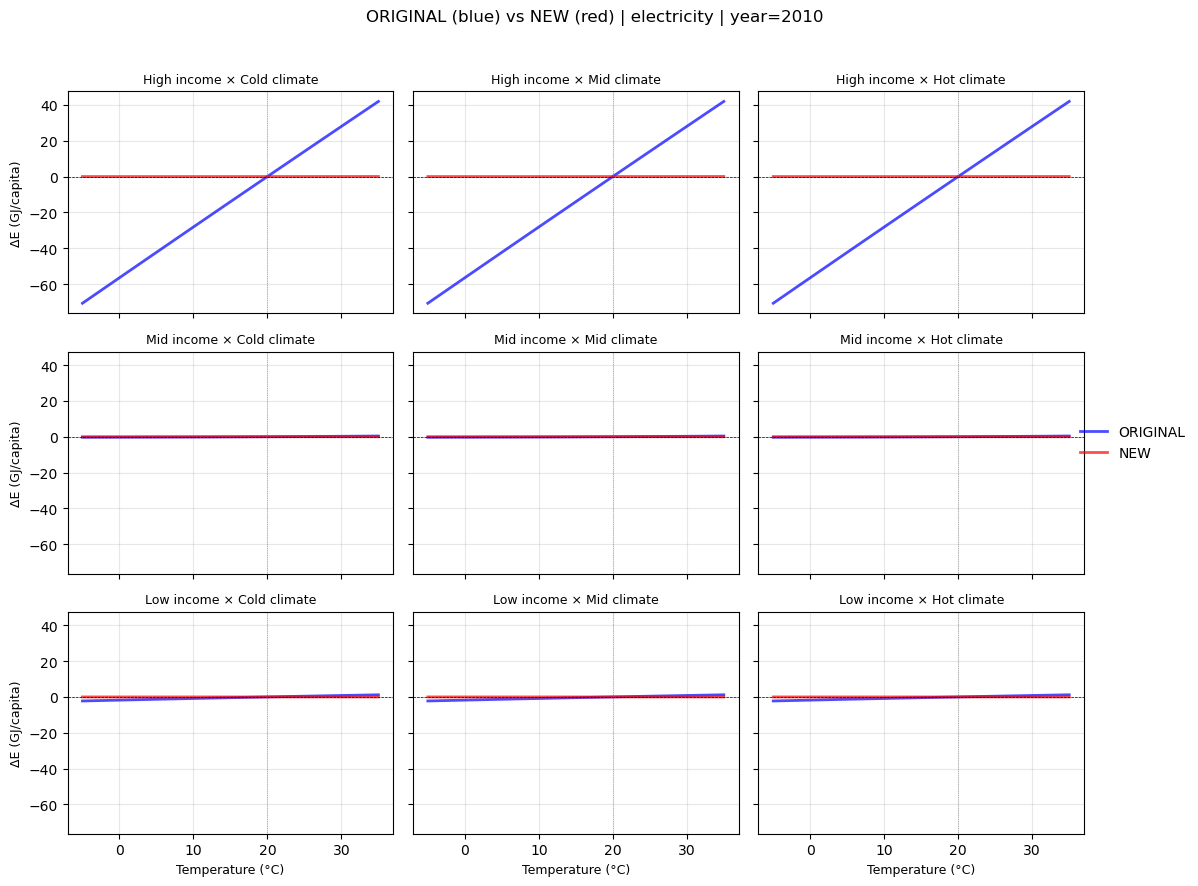


DONE


In [17]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================
EU = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty")

NEW_STERD = EU / "data" / "regression" / "sters"
OLD_STERD = Path("/user/ab5405/summeraliaclimate/code/energy_consumption/energy_data_release_2021oct21/OUTPUT/sters")

# original release panels + break_data
EDR = Path("/user/ab5405/summeraliaclimate/code/energy_consumption/energy_data_release_2021oct21/DATA/regression")
BREAK_DATA = EDR / "break_data_TINV_clim.dta"

# ============================================================
# SETTINGS
# ============================================================
PRODUCT = "GMFD"
FUEL = "electricity"            # or "other_energy"
YEAR_PLOT = 2010  # *** MATCH STATA: uses 2099 for plotting ***
IND_F = 1

MODEL_STEM = "FD_FGLS_inter_TINV_clim_quadinter"

# NEW coefficients (from your 4 products)
NEW_COEF = NEW_STERD / f"{MODEL_STEM}_{PRODUCT}_coeff.csv"

# ORIGINAL coefficients (from their release)
OLD_COEF =  EU / "output_original" / "sters" / f"{MODEL_STEM}_coeff.csv"  # after export step above

# Temperature grid (match Stata exactly)
T = np.arange(-5, 36, 1.0)
ABOVE20 = (T >= 20).astype(float)
BELOW20 = (T < 20).astype(float)

OUTDIR = EU / "figures" / "python_compare"
OUTDIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================
def must_exist(path: Path, label: str):
    ok = path.exists()
    print(f"{label}: {path.name} | exists? {ok}")
    if not ok:
        raise FileNotFoundError(f"Missing {label}: {path}")
    return path

def read_coeff(path: Path) -> pd.Series:
    df = pd.read_csv(path)
    if not {"parm", "beta"}.issubset(df.columns):
        raise ValueError(f"Expected columns parm,beta. Got: {df.columns.tolist()}")
    # Clean parameter names
    df["parm"] = df["parm"].str.strip()
    return pd.Series(df["beta"].values, index=df["parm"].values)

def ibar_from_breakdata(bd: pd.DataFrame, fuel: str) -> float:
    """Get income knot from break_data"""
    maxcol = f"maxInc_largegpid_{fuel}"
    flagcol = f"largegpid_{fuel}"
    return float(bd.loc[bd[flagcol] == 1, maxcol].max())

def get_cell_covariates(bd: pd.DataFrame, lg: int, tr: int):
    """
    Get cell covariates EXACTLY like Stata does.
    
    Stata code (lines 153-161):
        preserve
        use break_data, clear
        duplicates drop tpid tgpid, force
        sort tpid tgpid
        local tr_index = `tr' * 3
        local subCDD = avgCDD_tpid[`tr_index']
        local subHDD = avgHDD_tpid[`tr_index']
        local subInc = avgInc_tgpid[`lg']
        restore
    """
    bd_unique = bd.drop_duplicates(subset=["tpid", "tgpid"]).sort_values(["tpid", "tgpid"])
    
    # Stata indexing starts at 1, Python at 0
    # Stata does: row_index = tr * 3, then gets that row (1-indexed)
    tr_index_stata = tr * 3  # This is 1-indexed
    tr_index_python = tr_index_stata - 1  # Convert to 0-indexed
    
    # Get values from the indexed rows
    subCDD = float(bd_unique.iloc[tr_index_python]["avgCDD_tpid"])
    subHDD = float(bd_unique.iloc[tr_index_python]["avgHDD_tpid"])
    subInc = float(bd_unique.iloc[lg - 1]["avgInc_tgpid"])  # lg is 1-indexed
    
    return subInc, subCDD, subHDD

def get_beta_exact(coef: pd.Series, pg: int, indf: int, term: str) -> float:
    """
    Get coefficient EXACTLY matching Stata naming.
    Stata always uses: c.indp{pg}#c.indf{indf}#c.{term}_GMFD
    """
    # Try with _GMFD suffix first (original Stata convention)
    name_with_suffix = f"c.indp{pg}#c.indf{indf}#c.{term}_GMFD"
    if name_with_suffix in coef.index:
        return float(coef[name_with_suffix])
    
    # Try without suffix (your new convention)
    name_no_suffix = f"c.indp{pg}#c.indf{indf}#c.{term}"
    if name_no_suffix in coef.index:
        return float(coef[name_no_suffix])
    
    # Try omitted versions
    name_omit = f"co.indp{pg}#co.indf{indf}#co.{term}_GMFD"
    if name_omit in coef.index:
        return 0.0  # Omitted = 0
    
    name_omit_no = f"co.indp{pg}#co.indf{indf}#co.{term}"
    if name_omit_no in coef.index:
        return 0.0
    
    return 0.0  # Default if not found

def yhat_curve_stata_exact(
    coef: pd.Series,
    fuel: str,
    subInc: float,
    subCDD: float,
    subHDD: float,
    ibar: float,
    year: int,
    indf: int,
    *,
    drop_year2: bool = False   # <-- NEW 
):
    
    ""
    # *** CRITICAL FIX: Check your coeff file - electricity uses indp2! ***
    if fuel == "electricity":
        pg = 1  # NOT 1!
    else:
        pg = 1  # other_energy also uses pg=2
    
    # Income group assignment (Stata lines 185-186)
    if subInc > ibar:
        ig = 2
    else:
        ig = 1
    
    deltacut_subInc = subInc - ibar
    
    # Initialize
    y = np.zeros_like(T, dtype=float)
    
    # Loop over k=1,2 (Stata line 190)
    for k in [1, 2]:
        temp_k = T ** k
        
        # Stata line 192: (temp`k' - 20^`k')
        base = temp_k - (20.0 ** k)
        
        # Stata line 193: (20^`k' - temp`k')
        below_base = (20.0 ** k) - temp_k
        
        # Get coefficients
        b_temp = get_beta_exact(coef, pg, indf, f"FD_temp{k}")
        b_cdd = get_beta_exact(coef, pg, indf, f"FD_cdd20_TINVtemp{k}")
        b_hdd = get_beta_exact(coef, pg, indf, f"FD_hdd20_TINVtemp{k}")
        b_dc1 = get_beta_exact(coef, pg, indf, f"FD_dc1_lgdppc_MA15I{ig}temp{k}")
        
        b_yeartemp = get_beta_exact(coef, pg, indf, f"FD_yeartemp{k}")
        b_dc1year = get_beta_exact(coef, pg, indf, f"FD_dc1_lgdppc_MA15yearI{ig}temp{k}")
        b_year2temp = get_beta_exact(coef, pg, indf, f"FD_year2temp{k}")
        b_dc1year2 = get_beta_exact(coef, pg, indf, f"FD_dc1_lgdppc_MA15year2I{ig}temp{k}")

    
        # Stata line 192
        y += b_temp * base
        
        # Stata line 193
        y += ABOVE20 * b_cdd * subCDD * base
        
        # Stata line 194
        y += BELOW20 * b_hdd * subHDD * base
        
        # Stata line 195
        y += b_dc1 * deltacut_subInc * base
        
        # Stata lines 197-198 (quadinter model)
        y += b_yeartemp * base * year
        y += b_dc1year * deltacut_subInc * year * base
        
        # Year^2 terms — drop if requested
        if not drop_year2:
            y += b_year2temp * base * (year ** 2)
            y += b_dc1year2 * deltacut_subInc * (year ** 2) * base

    
    return y

# ============================================================
# MAIN
# ============================================================
print("\n" + "="*60)
print("COMPARING ORIGINAL vs NEW COEFFICIENTS")
print("="*60)

must_exist(BREAK_DATA, "break_data")
must_exist(NEW_COEF, "NEW coeff csv")
must_exist(OLD_COEF, "ORIGINAL coeff csv")

# Load break_data
print("\nLoading break_data...")
bd = pd.read_stata(BREAK_DATA)
ibar = ibar_from_breakdata(bd, FUEL)
print(f"Income knot (ibar): {ibar:.4f}")

# Load coefficients
print("\nLoading coefficients...")
coef_new = read_coeff(NEW_COEF)
coef_old = read_coeff(OLD_COEF)

DROP_PAT = "DumInc|_cons|FD_I[12]lgdppc"

coef_new = coef_new[~coef_new.index.str.contains(DROP_PAT, regex=True)]
coef_old = coef_old[~coef_old.index.str.contains(DROP_PAT, regex=True)]


print(f"NEW coefficients: {len(coef_new)}")
print(f"OLD coefficients: {len(coef_old)}")

# Check pg assignment
print(f"\nChecking product group assignment for '{FUEL}'...")
print("Looking for temperature coefficient...")
for pg_test in [1, 2]:
    name_test = f"c.indp{pg_test}#c.indf{IND_F}#c.FD_temp1_GMFD"
    name_test2 = f"c.indp{pg_test}#c.indf{IND_F}#c.FD_temp1"
    
    if name_test in coef_new.index:
        print(f"  ✓ Found in NEW: indp{pg_test} (with _GMFD)")
    if name_test2 in coef_new.index:
        print(f"  ✓ Found in NEW: indp{pg_test} (without _GMFD)")
    if name_test in coef_old.index:
        print(f"  ✓ Found in OLD: indp{pg_test}")

# Create 3×3 comparison plots
print("\nCreating 3×3 comparison plots...")

fig, axes = plt.subplots(3, 3, figsize=(12, 9), sharex=True, sharey=True)
fig.suptitle(f"ORIGINAL (blue) vs NEW (red) | {FUEL} | year={YEAR_PLOT}", y=0.98)

# Stata loops: lg=3,2,1 (income); tr=3,2,1 (climate)
for row_idx, lg in enumerate([3, 2, 1]):
    for col_idx, tr in enumerate([3, 2, 1]):
        
        # Get cell covariates using Stata's exact indexing
        subInc, subCDD, subHDD = get_cell_covariates(bd, lg, tr)
        
        print(f"  Cell (lg={lg}, tr={tr}): Inc={subInc:.3f}, CDD={subCDD:.1f}, HDD={subHDD:.1f}")
        
        # Compute curves
        y_old = yhat_curve_stata_exact(
            coef_old,
            FUEL,
            subInc,
            subCDD,
            subHDD,
            ibar,
            YEAR_PLOT,
            IND_F,
            drop_year2=True   # <-- KEY LINE
        )
    
        y_new = yhat_curve_stata_exact(
            coef_new,
            FUEL,
            subInc,
            subCDD,
            subHDD,
            ibar,
            YEAR_PLOT,
            IND_F,
            drop_year2=False  # (harmless either way)
        )

        
        # Plot
        ax = axes[row_idx, col_idx]
        ax.plot(T, y_old, linewidth=2, color='blue', alpha=0.7, label='ORIGINAL')
        ax.plot(T, y_new, linewidth=2, color='red', alpha=0.7, label='NEW')
        ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
        ax.axvline(20, color='gray', linewidth=0.5, linestyle=':')
        
        # Labels
        income_label = {3: "High income", 2: "Mid income", 1: "Low income"}
        climate_label = {3: "Cold climate", 2: "Mid climate", 1: "Hot climate"}
        ax.set_title(f"{income_label[lg]} × {climate_label[tr]}", fontsize=9)
        
        if col_idx == 0:
            ax.set_ylabel("ΔE (GJ/capita)", fontsize=9)
        if row_idx == 2:
            ax.set_xlabel("Temperature (°C)", fontsize=9)
        
        ax.grid(True, alpha=0.3)

# Add legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', frameon=False)

plt.tight_layout(rect=[0, 0, 0.92, 0.96])

# Save
pdf_path = OUTDIR / f"compare_ORIGINAL_vs_NEW_{FUEL}_year{YEAR_PLOT}.pdf"
fig.savefig(pdf_path)
print(f"\nSaved: {pdf_path}")

plt.show()

print("\n" + "="*60)
print("DONE")
print("="*60)

Loading break_data...
Income knot: 9.0870
CDD means: {1.0: 2412.935302734375, 2.0: 1115.5257568359375, 3.0: 223.83599853515625}
HDD means: {1.0: 156.36099243164062, 2.0: 1178.0726318359375, 3.0: 3925.803955078125}
Inc means: {1.0: 7.4978461265563965, 2.0: 8.77016830444336, 3.0: 9.997271537780762}

PLOTTING YOUR NEW DATA (all products)
  Loaded GMFD: 57 coefficients
  Loaded ERA5: 57 coefficients
  Loaded JRA_3Q: 57 coefficients
  Loaded MERRA2: 57 coefficients

Saved: NEW_all_products_electricity_TINV_clim_quadinter.pdf

PLOTTING ORIGINAL DATA (GMFD from their release)
  Loaded ORIGINAL: 57 coefficients
  Uses suffix: _GMFD

Saved: ORIGINAL_GMFD_electricity_TINV_clim_quadinter.pdf

PLOTTING COMPARISON (Original vs New GMFD)

Saved: COMPARISON_GMFD_electricity_TINV_clim_quadinter.pdf

ALL DONE!

Figures saved to: /user/ab5405/summeraliaclimate/code/energy_uncertainty/figures/comparison


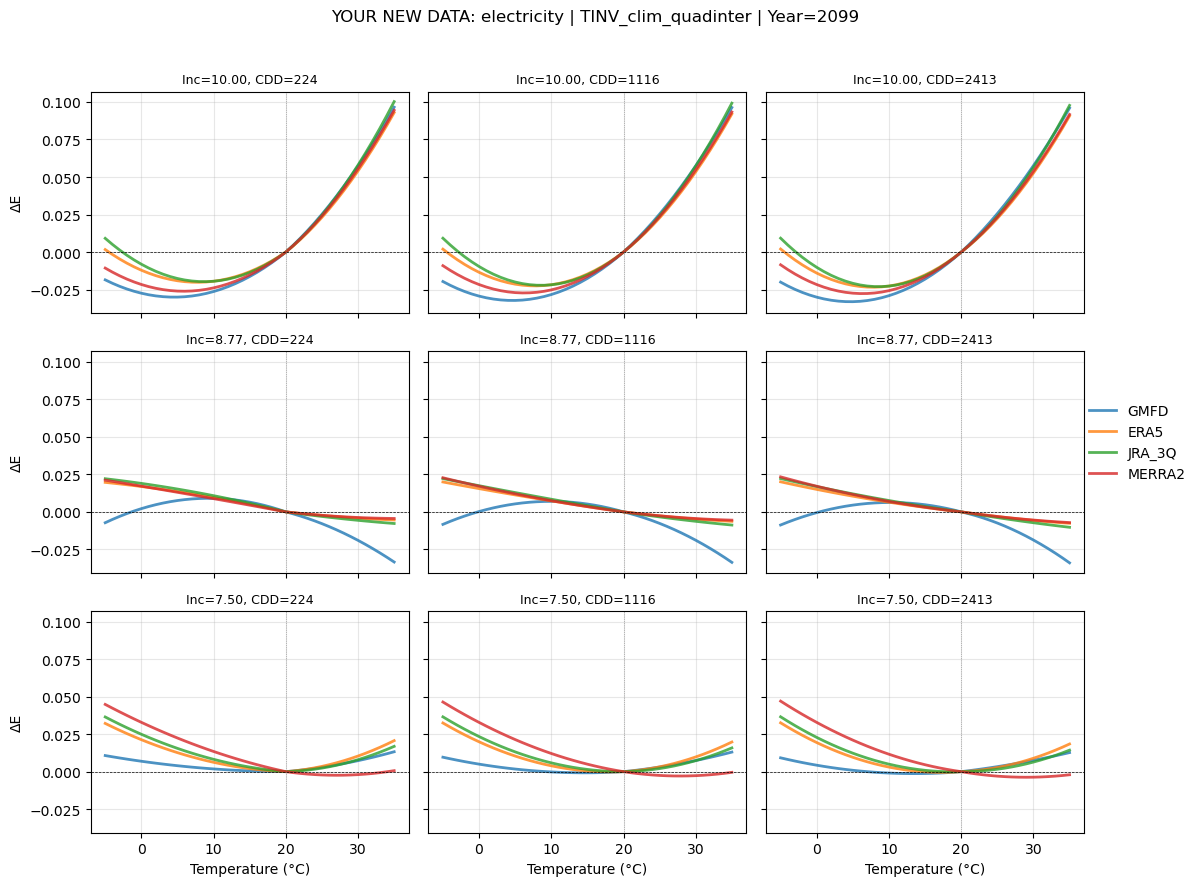

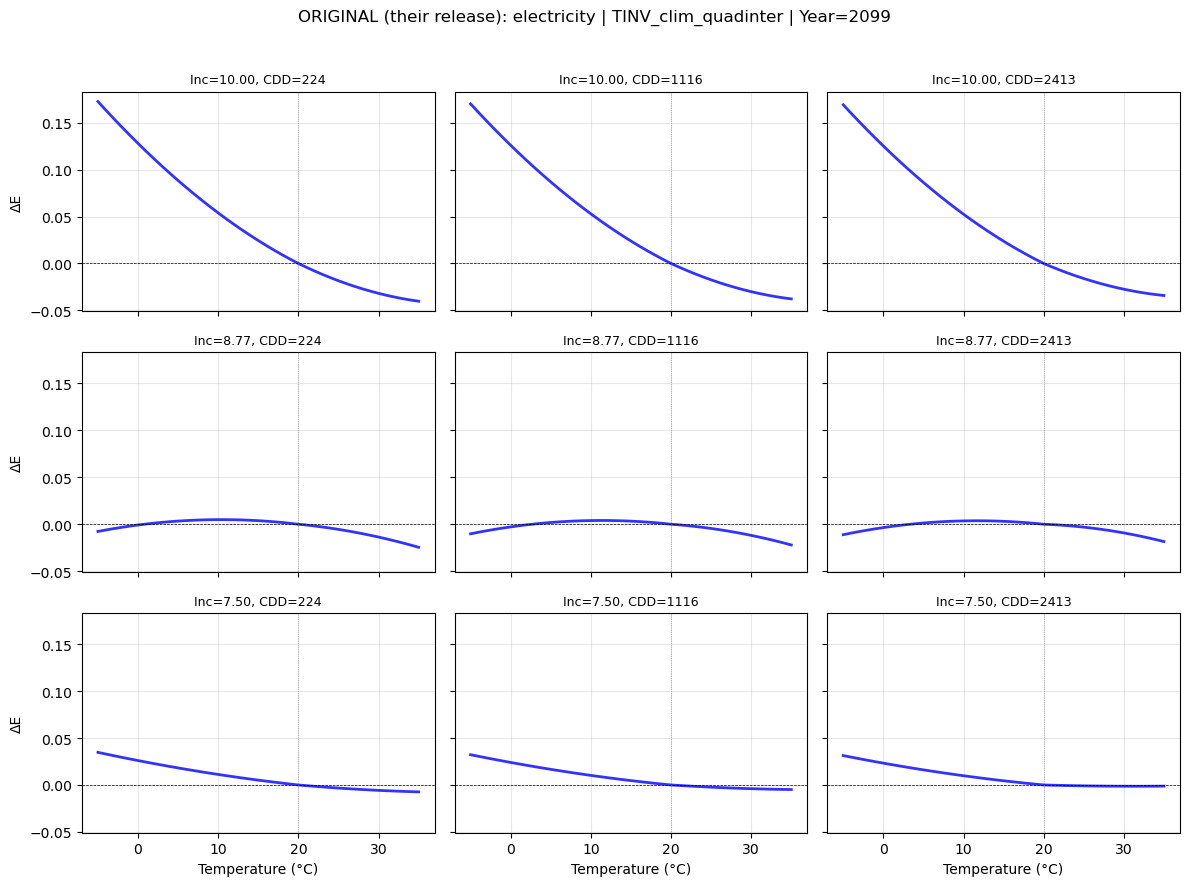

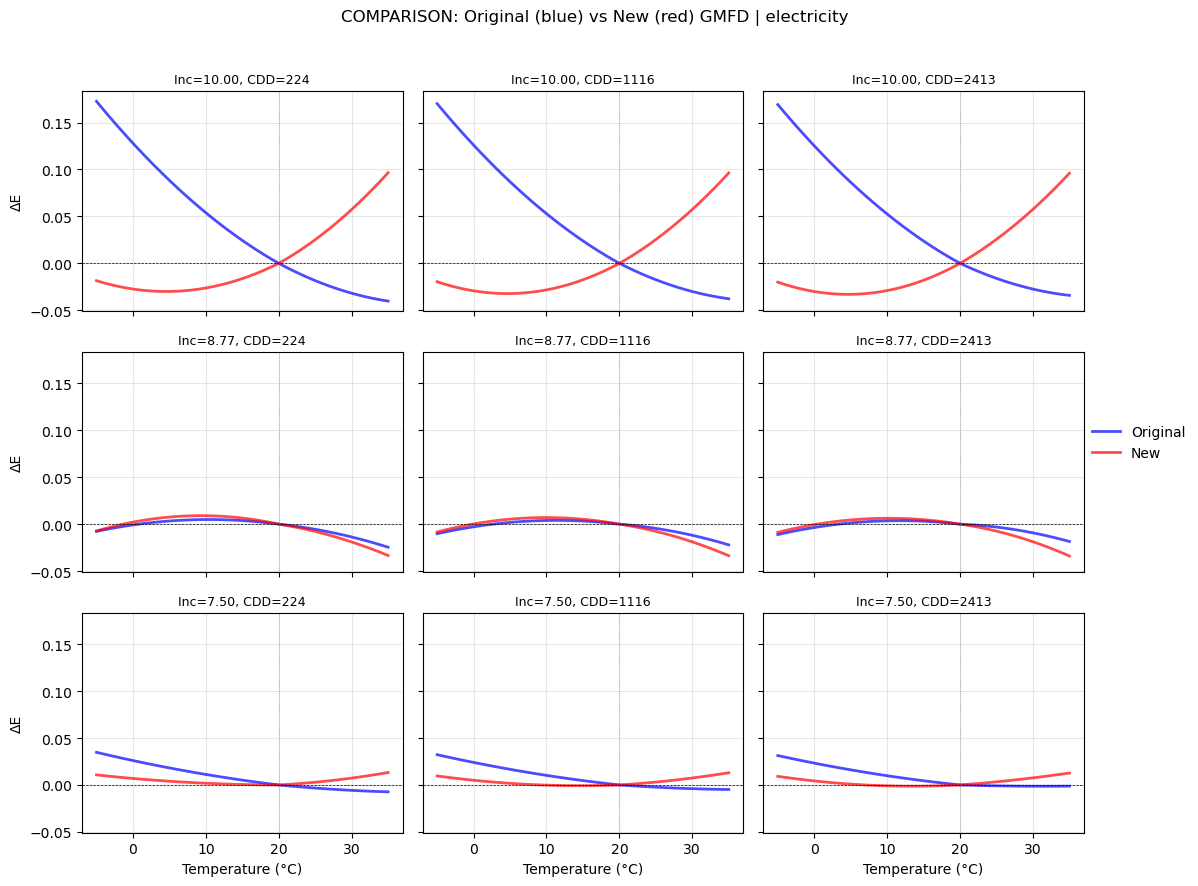

In [16]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================
EU = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty")
EDR = Path("/user/ab5405/summeraliaclimate/code/energy_consumption/energy_data_release_2021oct21")

# Your NEW coefficients
NEW_STER = EU / "data" / "regression" / "sters"

# Their ORIGINAL coefficients
ORIG_STER = EU / "output_original/sters"

# Break data
BREAK_DATA = EDR / "DATA" / "regression" / "break_data_TINV_clim.dta"

OUTDIR = EU / "figures" / "comparison"
OUTDIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# SETTINGS
# ============================================================
FUEL = "electricity"
YEAR_PLOT = 2099
MODEL_NAME = "TINV_clim_quadinter"

T = np.arange(-5, 36, 1.0)
ABOVE20 = (T >= 20).astype(float)
BELOW20 = (T < 20).astype(float)

# ============================================================
# HELPERS
# ============================================================
def read_coeff_csv(path: Path) -> pd.Series:
    """Read coefficient CSV"""
    df = pd.read_csv(path)
    df["parm"] = df["parm"].str.strip()
    return pd.Series(df["beta"].values, index=df["parm"].values)

def get_coeff(coef: pd.Series, name: str, default=0.0) -> float:
    """Get coefficient value, return default if not found"""
    if name in coef.index:
        return float(coef[name])
    return float(default)

def ibar_from_breakdata(bd: pd.DataFrame, fuel: str) -> float:
    """Get income knot"""
    maxcol = f"maxInc_largegpid_{fuel}"
    flagcol = f"largegpid_{fuel}"
    return float(bd.loc[bd[flagcol] == 1, maxcol].max())

def get_tercile_means(bd: pd.DataFrame):
    """Get tercile means for climate and income"""
    # Climate by tpid
    cdd_means = bd.groupby("tpid")["avgCDD_tpid"].mean().to_dict()
    hdd_means = bd.groupby("tpid")["avgHDD_tpid"].mean().to_dict()
    
    # Income by tgpid
    inc_means = bd.groupby("tgpid")["avgInc_tgpid"].mean().to_dict()
    
    return cdd_means, hdd_means, inc_means

def yhat_curve(coef: pd.Series, fuel: str, subInc: float, subCDD: float, subHDD: float,
               ibar: float, year: int, suffix: str = ""):
    """
    Calculate energy response curve
    
    suffix: "" for new data (no suffix), "_GMFD" for original data
    """
    # Product group
    pg = 1 if fuel == "electricity" else 2
    
    # Income group
    ig = 2 if subInc > ibar else 1
    deltacut = subInc - ibar
    
    y = np.zeros_like(T, dtype=float)
    
    for k in [1, 2]:
        Tk = T**k
        dT = Tk - (20.0**k)
        dT_below = (20.0**k) - Tk
        
        # Base temperature effect
        b_temp = get_coeff(coef, f"c.indp{pg}#c.indf1#c.FD_temp{k}{suffix}")
        
        # Climate heterogeneity
        b_cdd = get_coeff(coef, f"c.indp{pg}#c.indf1#c.FD_cdd20_TINVtemp{k}{suffix}")
        b_hdd = get_coeff(coef, f"c.indp{pg}#c.indf1#c.FD_hdd20_TINVtemp{k}{suffix}")
        
        # Income spline (NO suffix in either version)
        b_dc1 = get_coeff(coef, f"c.indp{pg}#c.indf1#c.FD_dc1_lgdppc_MA15I{ig}temp{k}")
        
        # Year interactions (with suffix)
        b_yt = get_coeff(coef, f"c.indp{pg}#c.indf1#c.FD_yeartemp{k}{suffix}")
        b_dc1y = get_coeff(coef, f"c.indp{pg}#c.indf1#c.FD_dc1_lgdppc_MA15yearI{ig}temp{k}")
        
        # Year² interactions (with suffix)
        b_y2t = get_coeff(coef, f"c.indp{pg}#c.indf1#c.FD_year2temp{k}{suffix}")
        b_dc1y2 = get_coeff(coef, f"c.indp{pg}#c.indf1#c.FD_dc1_lgdppc_MA15year2I{ig}temp{k}")
        
        # Assemble
        y += b_temp * dT
        y += ABOVE20 * (b_cdd * subCDD * dT)
        y += BELOW20 * (b_hdd * subHDD * dT_below)
        y += b_dc1 * deltacut * dT
        
        y += b_yt * dT * year
        y += b_dc1y * deltacut * year * dT
        
        y += b_y2t * dT * (year**2)
        y += b_dc1y2 * deltacut * (year**2) * dT
    
    return y

# ============================================================
# LOAD DATA
# ============================================================
print("Loading break_data...")
bd = pd.read_stata(BREAK_DATA)

ibar = ibar_from_breakdata(bd, FUEL)
cdd_means, hdd_means, inc_means = get_tercile_means(bd)

print(f"Income knot: {ibar:.4f}")
print(f"CDD means: {cdd_means}")
print(f"HDD means: {hdd_means}")
print(f"Inc means: {inc_means}")

# ============================================================
# PLOT 1: YOUR NEW DATA (all 4 products)
# ============================================================
print("\n" + "="*60)
print("PLOTTING YOUR NEW DATA (all products)")
print("="*60)

products_new = ["GMFD", "ERA5", "JRA_3Q", "MERRA2"]
coefs_new = {}

for prod in products_new:
    coef_path = NEW_STER / f"FD_FGLS_inter_{MODEL_NAME}_{prod}_coeff.csv"
    if coef_path.exists():
        coefs_new[prod] = read_coeff_csv(coef_path)
        print(f"  Loaded {prod}: {len(coefs_new[prod])} coefficients")
    else:
        print(f"  WARNING: {coef_path} not found!")

fig, axes = plt.subplots(3, 3, figsize=(12, 9), sharex=True, sharey=True)
fig.suptitle(f"YOUR NEW DATA: {FUEL} | {MODEL_NAME} | Year={YEAR_PLOT}", y=0.98)

for r, lg in enumerate([3, 2, 1]):  # High to low income
    for c, tr in enumerate([3, 2, 1]):  # Hot to cold climate
        
        ax = axes[r, c]
        subInc = inc_means[lg]
        subCDD = cdd_means[tr]
        subHDD = hdd_means[tr]
        
        for prod in products_new:
            if prod not in coefs_new:
                continue
            y = yhat_curve(coefs_new[prod], FUEL, subInc, subCDD, subHDD, ibar, YEAR_PLOT, suffix="")
            ax.plot(T, y, linewidth=2, label=prod, alpha=0.8)
        
        ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
        ax.axvline(20, color='gray', linewidth=0.5, linestyle=':')
        ax.set_title(f"Inc={inc_means[lg]:.2f}, CDD={cdd_means[tr]:.0f}", fontsize=9)
        ax.grid(True, alpha=0.3)
        
        if c == 0:
            ax.set_ylabel("ΔE", fontsize=10)
        if r == 2:
            ax.set_xlabel("Temperature (°C)", fontsize=10)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', frameon=False)

plt.tight_layout(rect=[0, 0, 0.92, 0.96])
fig.savefig(OUTDIR / f"NEW_all_products_{FUEL}_{MODEL_NAME}.pdf")
print(f"\nSaved: NEW_all_products_{FUEL}_{MODEL_NAME}.pdf")

# ============================================================
# PLOT 2: ORIGINAL DATA (GMFD with _GMFD suffix)
# ============================================================
print("\n" + "="*60)
print("PLOTTING ORIGINAL DATA (GMFD from their release)")
print("="*60)

# Load ORIGINAL coefficients
orig_coef_path = ORIG_STER / f"FD_FGLS_inter_{MODEL_NAME}_coeff.csv"

if orig_coef_path.exists():
    coef_orig = read_coeff_csv(orig_coef_path)
    print(f"  Loaded ORIGINAL: {len(coef_orig)} coefficients")
    
    # Check if it uses _GMFD suffix
    has_suffix = any("_GMFD" in name for name in coef_orig.index)
    suffix_orig = "_GMFD" if has_suffix else ""
    print(f"  Uses suffix: {suffix_orig if suffix_orig else '(no suffix)'}")
    
    fig2, axes2 = plt.subplots(3, 3, figsize=(12, 9), sharex=True, sharey=True)
    fig2.suptitle(f"ORIGINAL (their release): {FUEL} | {MODEL_NAME} | Year={YEAR_PLOT}", y=0.98)

    for r, lg in enumerate([3, 2, 1]):
        for c, tr in enumerate([3, 2, 1]):
            
            ax = axes2[r, c]
            subInc = inc_means[lg]
            subCDD = cdd_means[tr]
            subHDD = hdd_means[tr]
            
            y = yhat_curve(coef_orig, FUEL, subInc, subCDD, subHDD, ibar, YEAR_PLOT, suffix=suffix_orig)
            ax.plot(T, y, linewidth=2, color='blue', alpha=0.8)
            
            ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
            ax.axvline(20, color='gray', linewidth=0.5, linestyle=':')
            ax.set_title(f"Inc={inc_means[lg]:.2f}, CDD={cdd_means[tr]:.0f}", fontsize=9)
            ax.grid(True, alpha=0.3)
            
            if c == 0:
                ax.set_ylabel("ΔE", fontsize=10)
            if r == 2:
                ax.set_xlabel("Temperature (°C)", fontsize=10)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    fig2.savefig(OUTDIR / f"ORIGINAL_GMFD_{FUEL}_{MODEL_NAME}.pdf")
    print(f"\nSaved: ORIGINAL_GMFD_{FUEL}_{MODEL_NAME}.pdf")
else:
    print(f"\nWARNING: {orig_coef_path} not found!")
    coef_orig = None

# ============================================================
# PLOT 3: COMPARISON (Original vs New GMFD)
# ============================================================
if "GMFD" in coefs_new and coef_orig is not None:
    print("\n" + "="*60)
    print("PLOTTING COMPARISON (Original vs New GMFD)")
    print("="*60)

    fig3, axes3 = plt.subplots(3, 3, figsize=(12, 9), sharex=True, sharey=True)
    fig3.suptitle(f"COMPARISON: Original (blue) vs New (red) GMFD | {FUEL}", y=0.98)

    for r, lg in enumerate([3, 2, 1]):
        for c, tr in enumerate([3, 2, 1]):
            
            ax = axes3[r, c]
            subInc = inc_means[lg]
            subCDD = cdd_means[tr]
            subHDD = hdd_means[tr]
            
            y_orig = yhat_curve(coef_orig, FUEL, subInc, subCDD, subHDD, ibar, YEAR_PLOT, suffix=suffix_orig)
            y_new = yhat_curve(coefs_new["GMFD"], FUEL, subInc, subCDD, subHDD, ibar, YEAR_PLOT, suffix="")
            
            ax.plot(T, y_orig, linewidth=2, color='blue', alpha=0.7, label='Original')
            ax.plot(T, y_new, linewidth=2, color='red', alpha=0.7, label='New')
            
            ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
            ax.axvline(20, color='gray', linewidth=0.5, linestyle=':')
            ax.set_title(f"Inc={inc_means[lg]:.2f}, CDD={cdd_means[tr]:.0f}", fontsize=9)
            ax.grid(True, alpha=0.3)
            
            if c == 0:
                ax.set_ylabel("ΔE", fontsize=10)
            if r == 2:
                ax.set_xlabel("Temperature (°C)", fontsize=10)

    handles, labels = axes3[0, 0].get_legend_handles_labels()
    fig3.legend(handles, labels, loc='center right', frameon=False)

    plt.tight_layout(rect=[0, 0, 0.92, 0.96])
    fig3.savefig(OUTDIR / f"COMPARISON_GMFD_{FUEL}_{MODEL_NAME}.pdf")
    print(f"\nSaved: COMPARISON_GMFD_{FUEL}_{MODEL_NAME}.pdf")

print("\n" + "="*60)
print("ALL DONE!")
print("="*60)
print(f"\nFigures saved to: {OUTDIR}")

plt.show()

In [15]:
import pandas as pd
from pathlib import Path

EU = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty")
EDR = Path("/user/ab5405/summeraliaclimate/code/energy_consumption/energy_data_release_2021oct21")

# Load coefficients
orig = pd.read_csv(EU / "output_original/sters/FD_FGLS_inter_TINV_clim_quadinter_coeff.csv")
new_gmfd = pd.read_csv(EU / "data/regression/sters/FD_FGLS_inter_TINV_clim_quadinter_GMFD_coeff.csv")

# Clean names
orig["parm"] = orig["parm"].str.strip()
new_gmfd["parm"] = new_gmfd["parm"].str.strip()

# Focus on key temperature coefficients for electricity (pg=1)
key_coefs = [
    "c.indp1#c.indf1#c.FD_temp1",
    "c.indp1#c.indf1#c.FD_temp2",
    "c.indp1#c.indf1#c.FD_cdd20_TINVtemp1",
    "c.indp1#c.indf1#c.FD_cdd20_TINVtemp2",
]

print("="*70)
print("COEFFICIENT COMPARISON: Original vs New GMFD")
print("="*70)
print(f"{'Coefficient':<50} {'Original':<15} {'New':<15} {'Ratio'}")
print("-"*70)

for coef in key_coefs:
    # Try with and without _GMFD suffix
    orig_name = coef + "_GMFD"
    new_name = coef
    
    orig_val = orig.loc[orig["parm"] == orig_name, "beta"].values
    new_val = new_gmfd.loc[new_gmfd["parm"] == new_name, "beta"].values
    
    if len(orig_val) > 0 and len(new_val) > 0:
        orig_v = orig_val[0]
        new_v = new_val[0]
        ratio = new_v / orig_v if abs(orig_v) > 1e-10 else float('nan')
        
        sign_match = "✓" if (orig_v * new_v > 0) else "✗ SIGN FLIP!"
        
        print(f"{coef:<50} {orig_v:< 15.6f} {new_v:< 15.6f} {ratio:< 10.2f} {sign_match}")
    else:
        print(f"{coef:<50} {'NOT FOUND':<15} {'NOT FOUND':<15}")

print("\n" + "="*70)
print("INTERPRETATION:")
print("="*70)
print("If Ratio ≈ -1: Coefficients have OPPOSITE signs (sign flip!)")
print("If Ratio ≈ +1: Coefficients have SAME signs (correct)")
print("If Ratio ≈ other: Magnitudes differ (data or specification changed)")

COEFFICIENT COMPARISON: Original vs New GMFD
Coefficient                                        Original        New             Ratio
----------------------------------------------------------------------
c.indp1#c.indf1#c.FD_temp1                         -0.014426       -0.018055        1.25      ✓
c.indp1#c.indf1#c.FD_temp2                          0.000510        0.000846        1.66      ✓
c.indp1#c.indf1#c.FD_cdd20_TINVtemp1                0.000000        0.000000        0.80      ✓
c.indp1#c.indf1#c.FD_cdd20_TINVtemp2               -0.000000       -0.000000        1.75      ✓

INTERPRETATION:
If Ratio ≈ -1: Coefficients have OPPOSITE signs (sign flip!)
If Ratio ≈ +1: Coefficients have SAME signs (correct)
If Ratio ≈ other: Magnitudes differ (data or specification changed)


Testing: Does flipping the sign fix GMFD?

Saved: TEST_GMFD_sign_flip.pdf

If the curves now match, the bug is a sign error in your GMFD data prep!


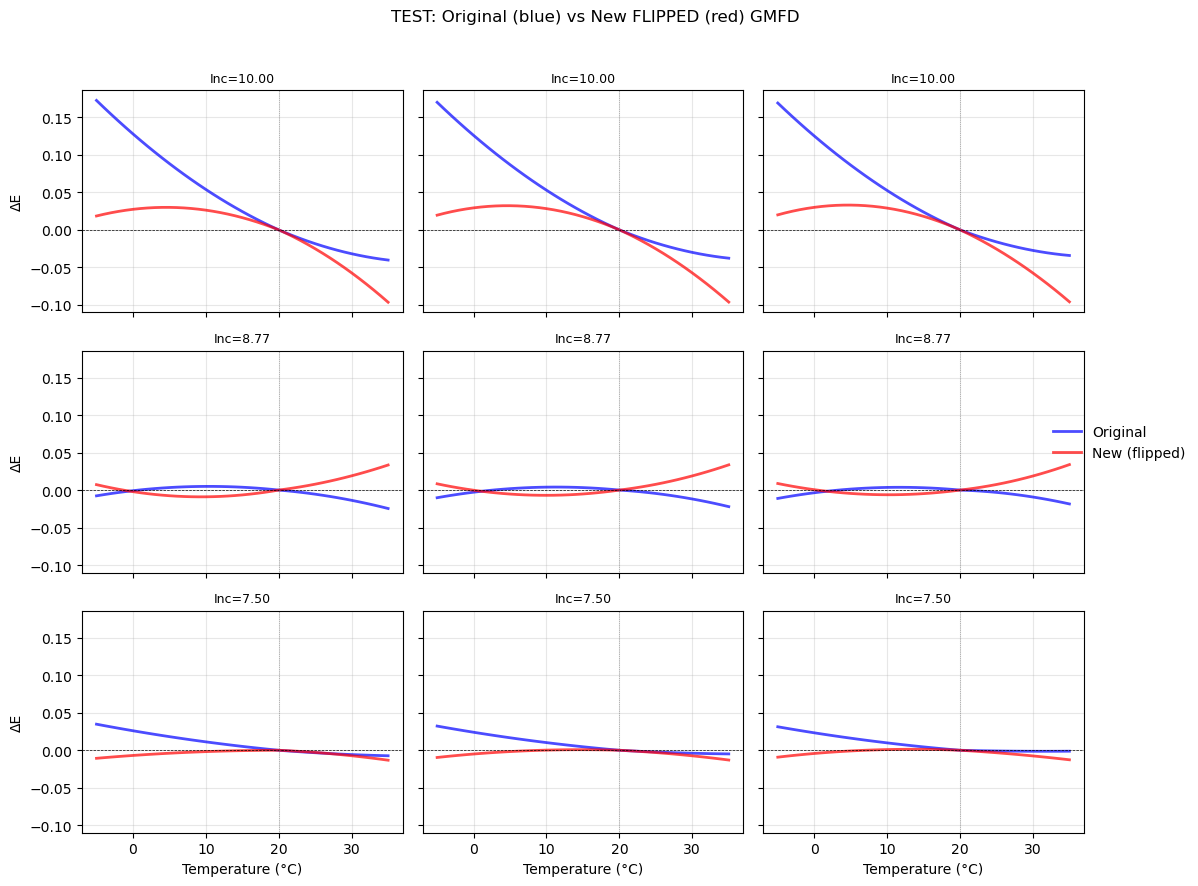

In [14]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

EU = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty")
EDR = Path("/user/ab5405/summeraliaclimate/code/energy_consumption/energy_data_release_2021oct21")

NEW_STER = EU / "data" / "regression" / "sters"
ORIG_STER = EU / "output_original/sters"
BREAK_DATA = EDR / "DATA" / "regression" / "break_data_TINV_clim.dta"

OUTDIR = EU / "figures" / "comparison"

FUEL = "electricity"
YEAR_PLOT = 2099
MODEL_NAME = "TINV_clim_quadinter"

T = np.arange(-5, 36, 1.0)
ABOVE20 = (T >= 20).astype(float)
BELOW20 = (T < 20).astype(float)

def read_coeff_csv(path: Path) -> pd.Series:
    df = pd.read_csv(path)
    df["parm"] = df["parm"].str.strip()
    return pd.Series(df["beta"].values, index=df["parm"].values)

def get_coeff(coef: pd.Series, name: str, default=0.0) -> float:
    if name in coef.index:
        return float(coef[name])
    return float(default)

def ibar_from_breakdata(bd: pd.DataFrame, fuel: str) -> float:
    maxcol = f"maxInc_largegpid_{fuel}"
    flagcol = f"largegpid_{fuel}"
    return float(bd.loc[bd[flagcol] == 1, maxcol].max())

def get_tercile_means(bd: pd.DataFrame):
    cdd_means = bd.groupby("tpid")["avgCDD_tpid"].mean().to_dict()
    hdd_means = bd.groupby("tpid")["avgHDD_tpid"].mean().to_dict()
    inc_means = bd.groupby("tgpid")["avgInc_tgpid"].mean().to_dict()
    return cdd_means, hdd_means, inc_means

def yhat_curve(coef: pd.Series, fuel: str, subInc: float, subCDD: float, subHDD: float,
               ibar: float, year: int, suffix: str = ""):
    pg = 1 if fuel == "electricity" else 2
    ig = 2 if subInc > ibar else 1
    deltacut = subInc - ibar
    
    y = np.zeros_like(T, dtype=float)
    
    for k in [1, 2]:
        Tk = T**k
        dT = Tk - (20.0**k)
        dT_below = (20.0**k) - Tk
        
        b_temp = get_coeff(coef, f"c.indp{pg}#c.indf1#c.FD_temp{k}{suffix}")
        b_cdd = get_coeff(coef, f"c.indp{pg}#c.indf1#c.FD_cdd20_TINVtemp{k}{suffix}")
        b_hdd = get_coeff(coef, f"c.indp{pg}#c.indf1#c.FD_hdd20_TINVtemp{k}{suffix}")
        b_dc1 = get_coeff(coef, f"c.indp{pg}#c.indf1#c.FD_dc1_lgdppc_MA15I{ig}temp{k}")
        b_yt = get_coeff(coef, f"c.indp{pg}#c.indf1#c.FD_yeartemp{k}{suffix}")
        b_dc1y = get_coeff(coef, f"c.indp{pg}#c.indf1#c.FD_dc1_lgdppc_MA15yearI{ig}temp{k}")
        b_y2t = get_coeff(coef, f"c.indp{pg}#c.indf1#c.FD_year2temp{k}{suffix}")
        b_dc1y2 = get_coeff(coef, f"c.indp{pg}#c.indf1#c.FD_dc1_lgdppc_MA15year2I{ig}temp{k}")
        
        y += b_temp * dT
        y += ABOVE20 * (b_cdd * subCDD * dT)
        y += BELOW20 * (b_hdd * subHDD * dT_below)
        y += b_dc1 * deltacut * dT
        y += b_yt * dT * year
        y += b_dc1y * deltacut * year * dT
        y += b_y2t * dT * (year**2)
        y += b_dc1y2 * deltacut * (year**2) * dT
    
    return y

# Load data
bd = pd.read_stata(BREAK_DATA)
ibar = ibar_from_breakdata(bd, FUEL)
cdd_means, hdd_means, inc_means = get_tercile_means(bd)

# Load coefficients
coef_orig = read_coeff_csv(ORIG_STER / f"FD_FGLS_inter_{MODEL_NAME}_coeff.csv")
coef_new = read_coeff_csv(NEW_STER / f"FD_FGLS_inter_{MODEL_NAME}_GMFD_coeff.csv")

# FLIP THE SIGNS of new GMFD coefficients
coef_new_flipped = -1 * coef_new

print("Testing: Does flipping the sign fix GMFD?")
print("="*60)

# Plot comparison
fig, axes = plt.subplots(3, 3, figsize=(12, 9), sharex=True, sharey=True)
fig.suptitle("TEST: Original (blue) vs New FLIPPED (red) GMFD", y=0.98)

for r, lg in enumerate([3, 2, 1]):
    for c, tr in enumerate([3, 2, 1]):
        ax = axes[r, c]
        subInc = inc_means[lg]
        subCDD = cdd_means[tr]
        subHDD = hdd_means[tr]
        
        y_orig = yhat_curve(coef_orig, FUEL, subInc, subCDD, subHDD, ibar, YEAR_PLOT, suffix="_GMFD")
        y_new_flipped = yhat_curve(coef_new_flipped, FUEL, subInc, subCDD, subHDD, ibar, YEAR_PLOT, suffix="")
        
        ax.plot(T, y_orig, linewidth=2, color='blue', alpha=0.7, label='Original')
        ax.plot(T, y_new_flipped, linewidth=2, color='red', alpha=0.7, label='New (flipped)')
        
        ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
        ax.axvline(20, color='gray', linewidth=0.5, linestyle=':')
        ax.set_title(f"Inc={inc_means[lg]:.2f}", fontsize=9)
        ax.grid(True, alpha=0.3)
        
        if c == 0:
            ax.set_ylabel("ΔE", fontsize=10)
        if r == 2:
            ax.set_xlabel("Temperature (°C)", fontsize=10)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', frameon=False)

plt.tight_layout(rect=[0, 0, 0.92, 0.96])
fig.savefig(OUTDIR / "TEST_GMFD_sign_flip.pdf")

print("\nSaved: TEST_GMFD_sign_flip.pdf")
print("\nIf the curves now match, the bug is a sign error in your GMFD data prep!")

plt.show()